# Pseudo Charts for measuring performance of the DT Framework

In [2]:
import matplotlib.pyplot as plt
import numpy as np

### Context:
All the performance measurements rely on the underlying components. So, before
testing the performance of the DT framework, the performance of each underlying
component must be captured (as they influence all other measurements).

- ZMQ PubSub backend
- AsyncFlow
- ROSE

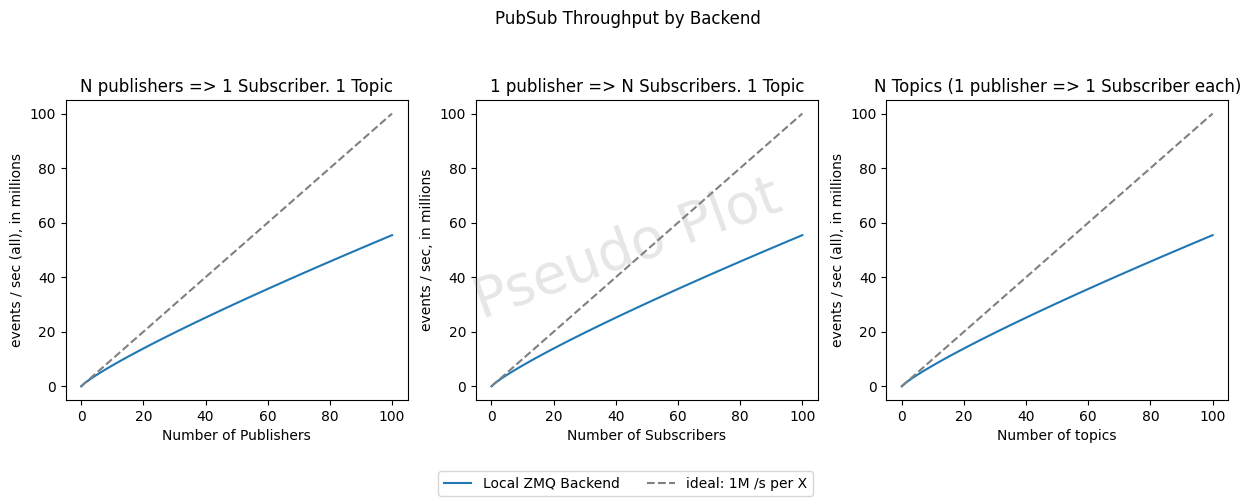

In [3]:
# PubSub backend measurements


x = np.linspace(0, 100, 101)

y = 1.050764356 * np.float_power(x, 0.8610870435)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))


# Publisher rate ----------------------

axes[0].set_title("N publishers => 1 Subscriber. 1 Topic")
axes[0].set_xlabel("Number of Publishers")
axes[0].set_ylabel("events / sec (all), in millions")

axes[0].plot(x, 1 * y, label="Local ZMQ Backend", zorder=1)
axes[0].plot(x, 1 * x, label="ideal: 1M /s per X", color="grey", linestyle="--")

# Subscriber rate --------------------
axes[1].set_title("1 publisher => N Subscribers. 1 Topic")
axes[1].set_xlabel("Number of Subscribers")
axes[1].set_ylabel("events / sec, in millions")

axes[1].plot(x, 1 * y, label="Local ZMQ Backend", zorder=1)
axes[1].plot(x, 1 * x, label="ideal: 1M /s per X", color="grey", linestyle="--")

# Topic count ----------------------------

axes[2].set_title("N Topics (1 publisher => 1 Subscriber each)")
axes[2].set_xlabel("Number of topics")
axes[2].set_ylabel("events / sec (all), in millions")

axes[2].plot(x, 1 * y, label="Local ZMQ Backend", zorder=1)
axes[2].plot(x, 1 * x, label="ideal: 1M /s per X", color="grey", linestyle="--")


fig.suptitle("PubSub Throughput by Backend")
fig.text(
    0.5, 0.5,
    "Pseudo Plot",
    fontsize=40,
    color="gray",
    alpha=0.2,
    ha="center",
    va="center",
    rotation=20,
    zorder=10,
)

handles, labels = axes[0].get_legend_handles_labels()

# One shared legend
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=2,
)

fig.subplots_adjust(wspace=0.2, bottom=0.2, top=0.8)
plt.show()


For below: all tasks wait 1 second and then end!
X axis: max concurrent tasks submitted.

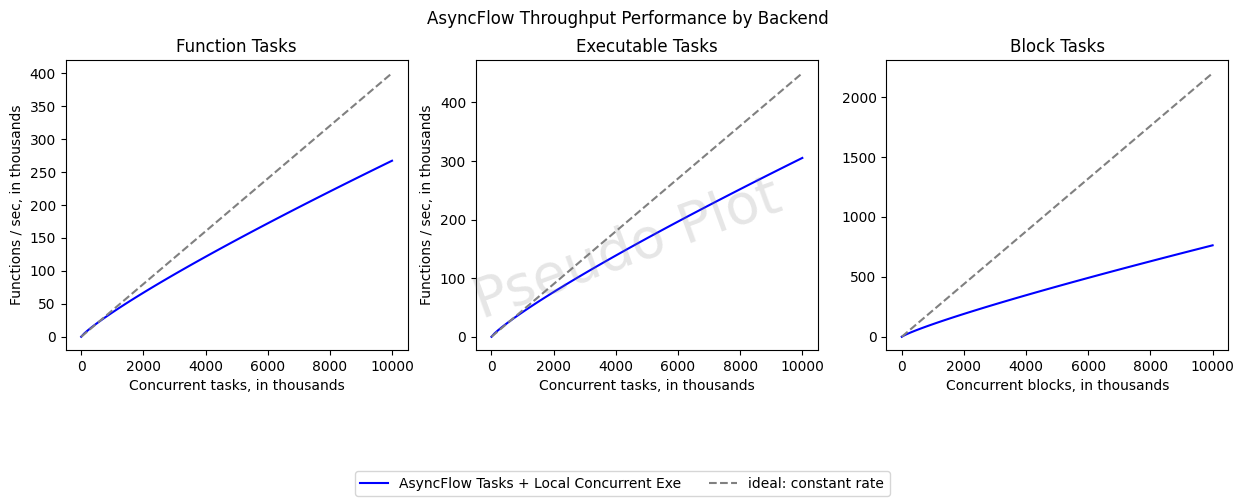

In [4]:
# AsyncFlow Function Rate


x = np.linspace(0, 10_000, 101)

y = 1.050764356 * np.float_power(x / 1_000, 0.8610870435)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))


# Function Tasks ----------------------
axes[0].set_title("Function Tasks")
axes[0].set_xlabel("Concurrent tasks, in thousands")
axes[0].set_ylabel("Functions / sec, in thousands")

axes[0].plot(x, 35 * y, label="AsyncFlow Tasks + Local Concurrent Exe", color="blue")
# axes[0].plot(x, 40 * y, label="control for local", color="blue",
# linestyle="--")
axes[0].plot(x, 40 * x / 1_000, label="ideal: constant rate", color="grey", linestyle="--")

# axes[0].text(
#     0.98, 0.02,
#     "control: asyncio + Executor",
#     transform=axes[0].transAxes,
#     ha="right",
#     va="bottom",
# )

# Executable Tasks --------------------
axes[1].set_title("Executable Tasks")
axes[1].set_xlabel("Concurrent tasks, in thousands")
axes[1].set_ylabel("Functions / sec, in thousands")

axes[1].plot(x, 40 * y, label="AsyncFlow Tasks + Local Concurrent Exe", color="blue")
# axes[1].plot(x, 45 * y, label="control for local", color="blue",
# linestyle="--")
axes[1].plot(x, 45 * x / 1_000, label="ideal: y=x", color="grey", linestyle="--")

# axes[1].text(
#     0.98, 0.02,
#     "control: asyncio + Executor + subprocess",
#     transform=axes[1].transAxes,
#     ha="right",
#     va="bottom",
# )

# Blocks ----------------------------

axes[2].set_title("Block Tasks")
axes[2].set_xlabel("Concurrent blocks, in thousands")
axes[1].set_ylabel("Functions / sec, in thousands")

axes[2].plot(x, 100 * y, label="Local", zorder=1, color="blue")
axes[2].plot(x, 220 * x / 1_000, label="ideal: y=x", color="grey", linestyle="--")
# axes[2].text(
#     0.98, 0.02,
#     "control: asyncio only",
#     transform=axes[2].transAxes,
#     ha="right",
#     va="bottom",
# )


fig.suptitle("AsyncFlow Throughput Performance by Backend")
fig.text(
    0.5, 0.5,
    "Pseudo Plot",
    fontsize=40,
    color="gray",
    alpha=0.2,
    ha="center",
    va="center",
    rotation=20,
    zorder=10,
)

handles, labels = axes[0].get_legend_handles_labels()

# One shared legend
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=2,
)

fig.subplots_adjust(wspace=0.2, bottom=0.3)
plt.show()


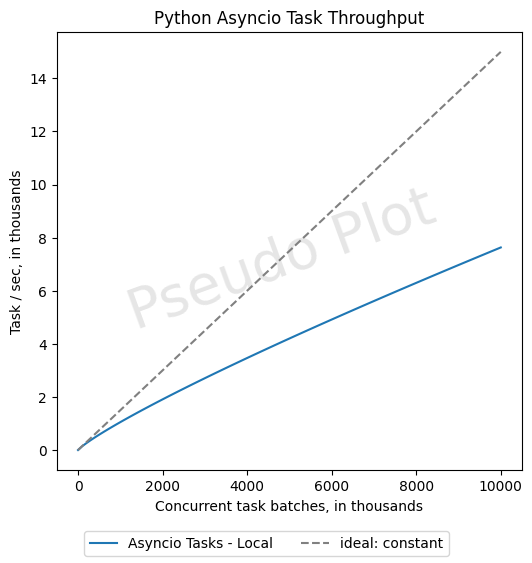

In [5]:
# AsyncFlow Function Rate


x = np.linspace(0, 10_000, 101)

y = 1.050764356 * np.float_power(x / 1_000, 0.8610870435)

fig, axes = plt.subplots(1, 1, figsize=(6, 6))


# Function Tasks ----------------------
axes.set_title("Python Asyncio Task Throughput")
axes.set_xlabel("Concurrent task batches, in thousands")
axes.set_ylabel("Task / sec, in thousands")

axes.plot(x, y, label="Asyncio Tasks - Local", zorder=1)
axes.plot(x, 1.5 * x / 1_000, label="ideal: constant", color="grey", linestyle="--")


# fig.suptitle("")
fig.text(
    0.5, 0.5,
    "Pseudo Plot",
    fontsize=40,
    color="gray",
    alpha=0.2,
    ha="center",
    va="center",
    rotation=20,
    zorder=10,
)

handles, labels = axes.get_legend_handles_labels()

# One shared legend
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=2,
)

fig.subplots_adjust(wspace=0.2, bottom=0.15)
plt.show()


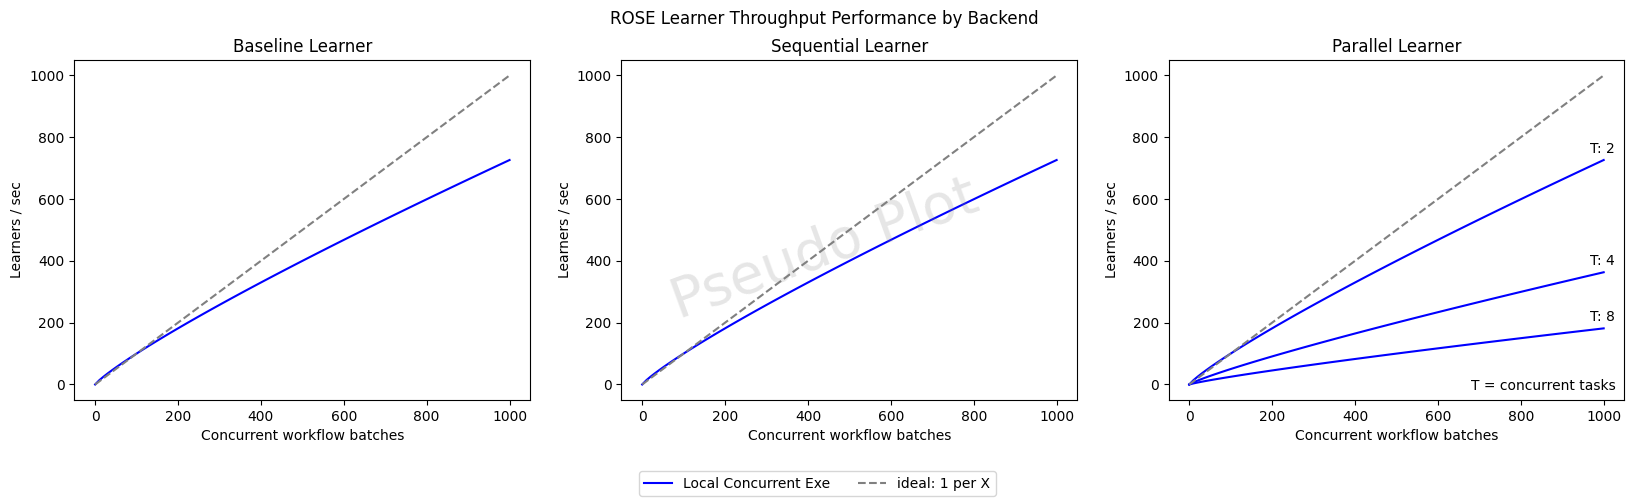

In [6]:
# ROSE Function Rate


x = np.linspace(0, 1_000, 101)

y = 1.0 * np.float_power(x / 100, 0.8610870435)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))


# Baseline  ----------------------

axes[0].set_title("Baseline Learner")
axes[0].set_xlabel("Concurrent workflow batches")
axes[0].set_ylabel("Learners / sec")

axes[0].plot(x, 100 * y, label="Local Concurrent Exe", zorder=1, color="blue")
axes[0].plot(x, x, label="ideal: 1 per X", color="grey", linestyle="--")

# Sequential  --------------------
axes[1].set_title("Sequential Learner")
axes[1].set_xlabel("Concurrent workflow batches")
axes[1].set_ylabel("Learners / sec")

axes[1].plot(x, 100 * y, label="Local Concurrent Exe", zorder=1, color="blue")
axes[1].plot(x, x, label="ideal", color="grey", linestyle="--")

# Parallel  --------------------
axes[2].set_title("Parallel Learner")
axes[2].set_xlabel("Concurrent workflow batches")
axes[2].set_ylabel("Learners / sec")
axes[2].plot(x, 50 * y, zorder=1, color="blue")
axes[2].plot(x, 25 * y, zorder=1, color="blue")
axes[2].annotate(
    "T: 2",
    xy=(x[-1], 100 * y[-1]),       # point on the line
    xytext=(-10, 5),       # offset in points
    textcoords="offset points",
)
axes[2].annotate(
    "T: 4",
    xy=(x[-1], 50 * y[-1]),       # point on the line
    xytext=(-10, 5),       # offset in points
    textcoords="offset points",
)
axes[2].annotate(
    "T: 8",
    xy=(x[-1], 25 * y[-1]),       # point on the line
    xytext=(-10, 5),       # offset in points
    textcoords="offset points",
)
axes[2].text(
    0.98, 0.02,
    "T = concurrent tasks",
    transform=axes[2].transAxes,
    ha="right",
    va="bottom",
)
axes[2].plot(x, 100 * y, label="Local Concurrent Exe",color="blue", zorder=1)
axes[2].plot(x, x, label="ideal", color="grey", linestyle="--")

fig.suptitle("ROSE Learner Throughput Performance by Backend")
fig.text(
    0.5, 0.5,
    "Pseudo Plot",
    fontsize=40,
    color="gray",
    alpha=0.2,
    ha="center",
    va="center",
    rotation=20,
    zorder=10,
)

handles, labels = axes[0].get_legend_handles_labels()

# One shared legend
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=2,
)

fig.subplots_adjust(wspace=0.2, bottom=0.2)
plt.show()


# Now: DT Graphs. 

Tasks in these experiments are nop. They *do not wait 1 second* unlike above.

They are broken across two orthogonal axes:

| | In-Situ Performance | Ex-Situ Performance |
|-|-|-|
| Multi Physics | # agents --> events processed per sec | events received --> learners complete |
|               |                                       | learner loops --> model updates       |
| | | 
| Multi Streams | # parallel agents --> events processed per sec | # parallel agents --> learner loops | 
|               | # of inputs --> events processed per second | # events (data join) --> learner loops |

## Multi-Physics VS In-Situ Performance

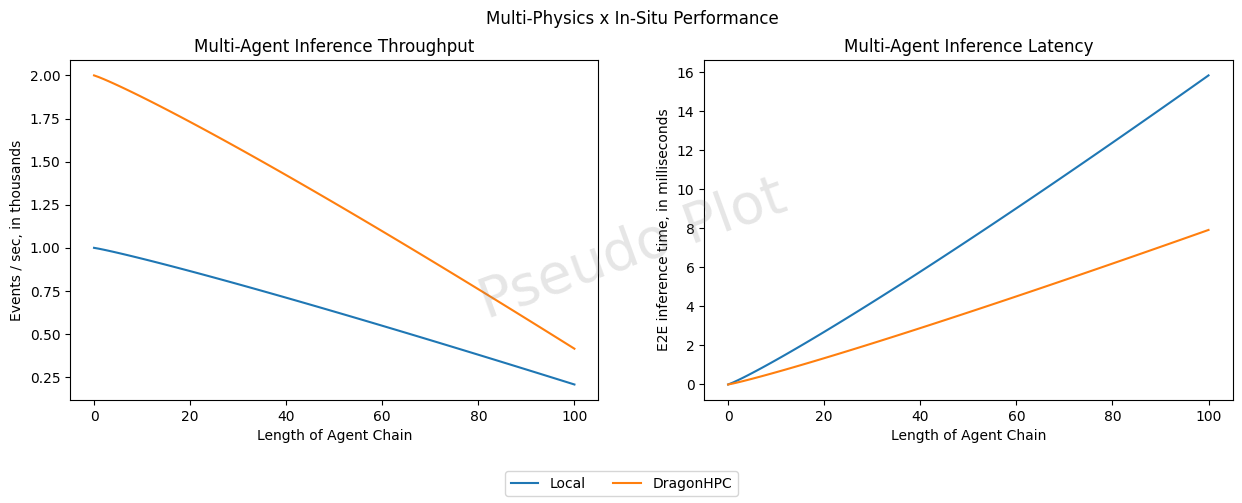

In [7]:

x = np.linspace(0, 100, 101)
flat = 0 * x + 1 
y = 1 - 0.005 * np.float_power(x, 1.10)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))


# Throughput  ----------------------

axes[0].set_title("Multi-Agent Inference Throughput")
axes[0].set_xlabel("Length of Agent Chain")
axes[0].set_ylabel("Events / sec, in thousands")

axes[0].plot(x, y, label="Local", zorder=1)
axes[0].plot(x, 2 * y, label="DragonHPC", zorder=1)
# axes[0].plot(x, flat, label="ideal", color="grey", linestyle="--")

# Latency  ----------------------

axes[1].set_title("Multi-Agent Inference Latency")
axes[1].set_xlabel("Length of Agent Chain")
axes[1].set_ylabel("E2E inference time, in milliseconds")

axes[1].plot(x, (1 - y) * 20, label="Local", zorder=1)
axes[1].plot(x, (1 - y) * 10, label="DragonHPC", zorder=1)
# axes[1].plot(x, 0 * x, label="ideal: 1 per X", color="grey", linestyle="--")


fig.suptitle("Multi-Physics x In-Situ Performance")
fig.text(
    0.5, 0.5,
    "Pseudo Plot",
    fontsize=40,
    color="gray",
    alpha=0.2,
    ha="center",
    va="center",
    rotation=20,
    zorder=10,
)

handles, labels = axes[0].get_legend_handles_labels()

# One shared legend
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=2,
)

fig.subplots_adjust(wspace=0.2, bottom=0.2)
plt.show()


## Multi-Physics VS Ex-Situ Performance

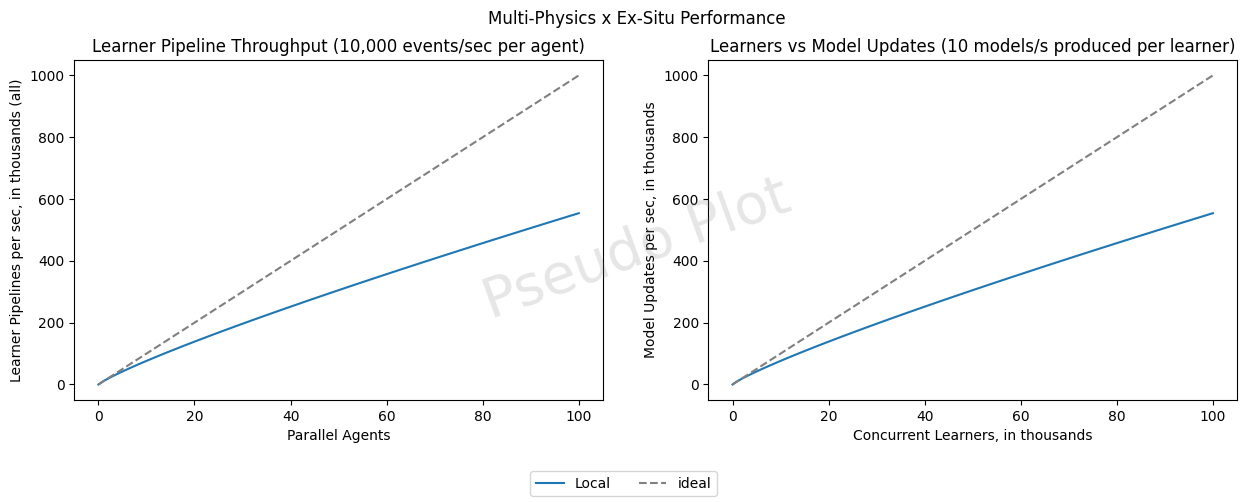

In [35]:


x = np.linspace(0, 100, 101)
y = 1.050764356 * np.float_power(x, 0.8610870435)
y2 = 1 - 0.005 * np.float_power(x, 1.10)
flat = 0 * x + 1
fig, axes = plt.subplots(1, 2, figsize=(15, 5))


# Learner maximum  ----------------------

axes[0].set_title("Learner Pipeline Throughput (10,000 events/sec per agent)")
axes[0].set_xlabel("Parallel Agents")
axes[0].set_ylabel("Learner Pipelines per sec, in thousands (all)")

axes[0].plot(x,10 * y, label="Local", zorder=1)
axes[0].plot(x,10 * x, label="ideal", color="grey", linestyle="--")

# Model Update Maximum  ----------------------

axes[1].set_title("Learners vs Model Updates (10 models/s produced per learner)")
axes[1].set_xlabel("Concurrent Learners, in thousands")
axes[1].set_ylabel("Model Updates per sec, in thousands")

axes[1].plot(x, 10 * y, label="Local", zorder=1)
axes[1].plot(x, 10 * x, label="ideal", color="grey", linestyle="--")


fig.suptitle("Multi-Physics x Ex-Situ Performance")
fig.text(
    0.5, 0.5,
    "Pseudo Plot",
    fontsize=40,
    color="gray",
    alpha=0.2,
    ha="center",
    va="center",
    rotation=20,
    zorder=10,
)

handles, labels = axes[0].get_legend_handles_labels()

# One shared legend
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=2,
)

fig.subplots_adjust(wspace=0.2, bottom=0.2)
plt.show()


## Multi Streams x In-Situ Performance

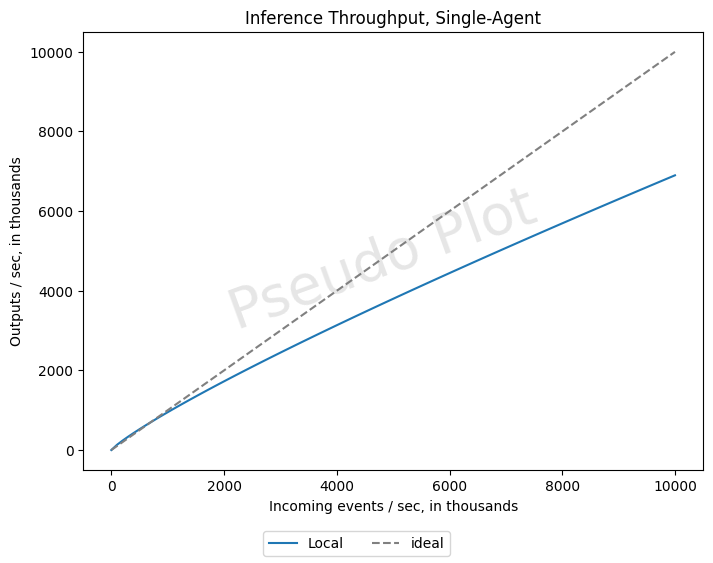

In [29]:
# Base throughput rate.

x = np.linspace(0, 10_000, 101)

y = 0.95 * np.float_power(x / 1_000, 0.8610870435)

fig, axes = plt.subplots(1, 1, figsize=(8, 6))


# Function Tasks ----------------------
axes.set_title("Inference Throughput, Single-Agent")
axes.set_xlabel("Incoming events / sec, in thousands")
axes.set_ylabel("Outputs / sec, in thousands")

axes.plot(x, 1000 * y, label="Local", zorder=1)
axes.plot(x, x, label="ideal", color="grey", linestyle="--")


# fig.suptitle("")
fig.text(
    0.5, 0.5,
    "Pseudo Plot",
    fontsize=40,
    color="gray",
    alpha=0.2,
    ha="center",
    va="center",
    rotation=20,
    zorder=10,
)

handles, labels = axes.get_legend_handles_labels()

# One shared legend
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=2,
)

fig.subplots_adjust(wspace=0.2, bottom=0.15)
plt.show()

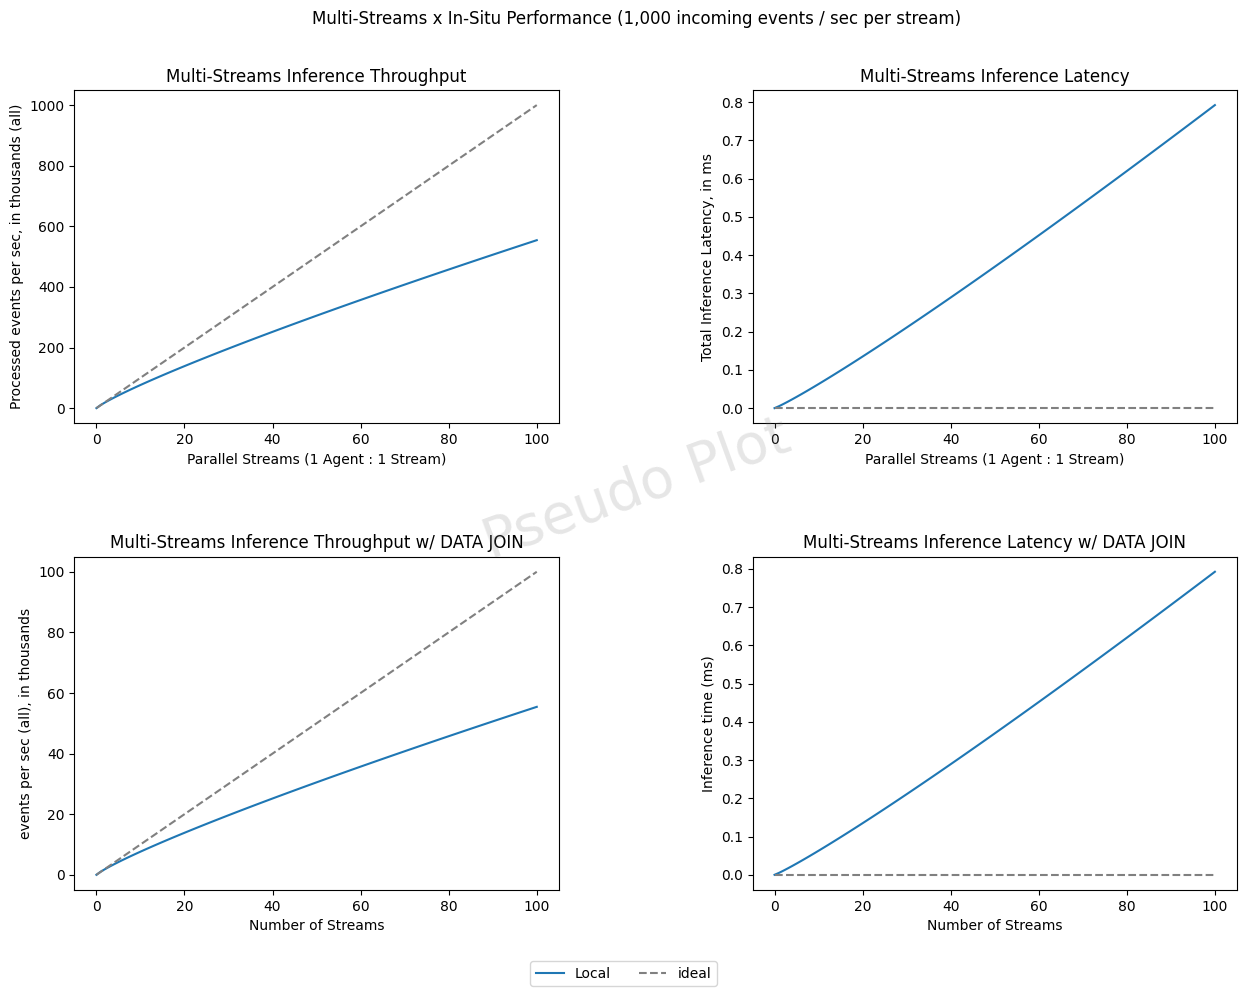

In [34]:

x = np.linspace(0, 100, 101)
flat = 0 * x + 1 
y = 1.050764356 * np.float_power(x, 0.8610870435)
y2 = 0.005 * np.float_power(x, 1.10)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))


# Throughput  ----------------------

axes[0, 0].set_title("Multi-Streams Inference Throughput")
axes[0, 0].set_xlabel("Parallel Streams (1 Agent : 1 Stream)")
axes[0, 0].set_ylabel("Processed events per sec, in thousands (all)")

axes[0, 0].plot(x, 10 * y, label="Local", zorder=1)
axes[0, 0].plot(x, 10 * x, label="ideal", color="grey", linestyle="--")

# Latency  ----------------------

axes[0, 1].set_title("Multi-Streams Inference Latency")
axes[0, 1].set_xlabel("Parallel Streams (1 Agent : 1 Stream)")
axes[0, 1].set_ylabel("Total Inference Latency, in ms")

axes[0, 1].plot(x, y2, label="Local", zorder=1)
axes[0, 1].plot(x,0 * x, label="ideal: 1 per X", color="grey", linestyle="--")


# Throughput  - DATA JOIN ----------------------

axes[1, 0].set_title("Multi-Streams Inference Throughput w/ DATA JOIN")
axes[1, 0].set_xlabel("Number of Streams")
axes[1, 0].set_ylabel("events per sec (all), in thousands")

axes[1, 0].plot(x, y, label="Local", zorder=1)
axes[1, 0].plot(x, x, label="ideal: 1 per X", color="grey", linestyle="--")

# Latency  ----------------------

axes[1, 1].set_title("Multi-Streams Inference Latency w/ DATA JOIN")
axes[1, 1].set_xlabel("Number of Streams")
axes[1, 1].set_ylabel("Inference time (ms)")

axes[1, 1].plot(x, y2, label="Local", zorder=1)
axes[1, 1].plot(x,0 * x, label="ideal: 1 per X", color="grey", linestyle="--")


fig.suptitle("Multi-Streams x In-Situ Performance (1,000 incoming events / sec per stream)")
fig.text(
    0.5, 0.5,
    "Pseudo Plot",
    fontsize=40,
    color="gray",
    alpha=0.2,
    ha="center",
    va="center",
    rotation=20,
    zorder=10,
)

handles, labels = axes[0,0].get_legend_handles_labels()

# One shared legend
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=2,
)

fig.subplots_adjust(hspace=0.4, wspace=0.4, bottom=0.1, top=0.9)
plt.show()


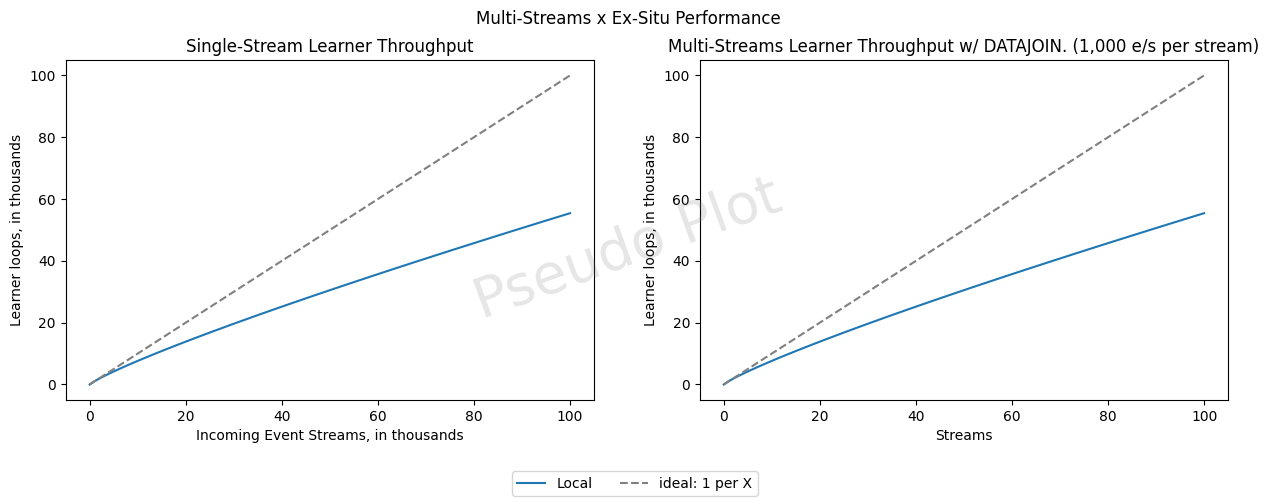

In [36]:

x = np.linspace(0, 100, 101)
flat = 0 * x + 1 
y = 1.050764356 * np.float_power(x, 0.8610870435)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))


# Throughput  ----------------------

axes[0].set_title("Single-Stream Learner Throughput")
axes[0].set_xlabel("Incoming Event Streams, in thousands")
axes[0].set_ylabel("Learner loops, in thousands")

axes[0].plot(x, y, label="Local", zorder=1)
axes[0].plot(x, x, label="ideal: 1 per X", color="grey", linestyle="--")

# Latency  ----------------------

axes[1].set_title("Multi-Streams Learner Throughput w/ DATAJOIN. (1,000 e/s per stream)")
axes[1].set_xlabel("Streams")
axes[1].set_ylabel("Learner loops, in thousands")

axes[1].plot(x, y, label="Local", zorder=1)
axes[1].plot(x, x, label="ideal: 1 per X", color="grey", linestyle="--")



fig.suptitle("Multi-Streams x Ex-Situ Performance")
fig.text(
    0.5, 0.5,
    "Pseudo Plot",
    fontsize=40,
    color="gray",
    alpha=0.2,
    ha="center",
    va="center",
    rotation=20,
    zorder=10,
)

handles, labels = axes[0].get_legend_handles_labels()

# One shared legend
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=2,
)

fig.subplots_adjust(wspace=0.2, bottom=0.2)
plt.show()



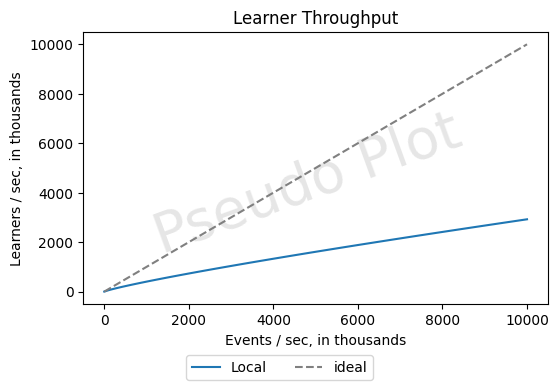

In [59]:
# Base throughput rate.

x = np.linspace(0, 10_000, 101)

y = 1.050764356 * np.float_power(x, 0.8610870435)

fig, axes = plt.subplots(1, 1, figsize=(6, 4))


# Function Tasks ----------------------
axes.set_title("Learner Throughput")
axes.set_xlabel("Events / sec, in thousands")
axes.set_ylabel("Learners / sec, in thousands")

axes.plot(x, y, label="Local", zorder=1)
axes.plot(x, x, label="ideal", color="grey", linestyle="--")


# fig.suptitle("")
fig.text(
    0.5, 0.5,
    "Pseudo Plot",
    fontsize=40,
    color="gray",
    alpha=0.2,
    ha="center",
    va="center",
    rotation=20,
    zorder=10,
)

handles, labels = axes.get_legend_handles_labels()

# One shared legend
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=2,
)

fig.subplots_adjust(wspace=0.2, bottom=0.2)
plt.show()

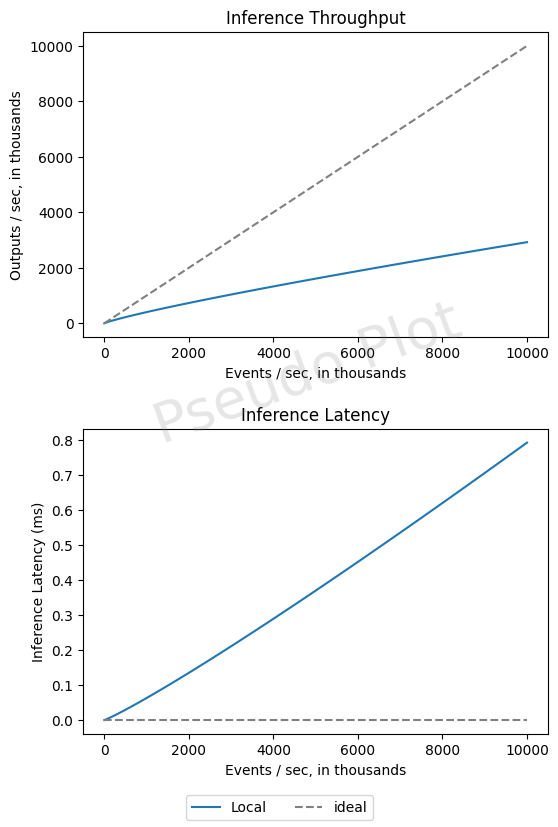

In [55]:
# Base throughput rate.

x = np.linspace(0, 10_000, 101)

y = 1.050764356 * np.float_power(x, 0.8610870435)
y2 = 0.005 * np.float_power(x / 100, 1.10)

fig, axes = plt.subplots(2, 1, figsize=(6, 9))


# Function Tasks ----------------------
axes[0].set_title("Inference Throughput")
axes[0].set_xlabel("Events / sec, in thousands")
axes[0].set_ylabel("Outputs / sec, in thousands")

axes[0].plot(x, y, label="Local", zorder=1)
axes[0].plot(x, x, label="ideal", color="grey", linestyle="--")

axes[1].set_title("Inference Latency")
axes[1].set_xlabel("Events / sec, in thousands")
axes[1].set_ylabel("Inference Latency (ms)")

axes[1].plot(x, y2, label="Local", zorder=1)
axes[1].plot(x, 0 * flat, label="ideal", color="grey", linestyle="--")


# fig.suptitle("")
fig.text(
    0.5, 0.5,
    "Pseudo Plot",
    fontsize=40,
    color="gray",
    alpha=0.2,
    ha="center",
    va="center",
    rotation=20,
    zorder=10,
)

handles, labels = axes[0].get_legend_handles_labels()

# One shared legend
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=2,
)

fig.subplots_adjust(hspace=0.3, bottom=0.1)
plt.show()

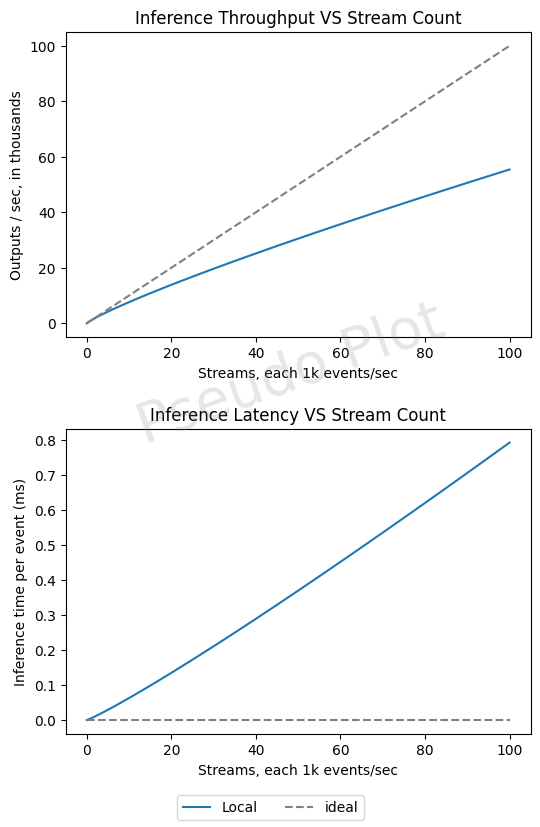

In [67]:
# Base throughput rate.

x = np.linspace(0, 100, 101)

y = 1.050764356 * np.float_power(x, 0.8610870435)
y2 = 0.005 * np.float_power(x, 1.10)

fig, axes = plt.subplots(2, 1, figsize=(6, 9))


# Function Tasks ----------------------
axes[0].set_title("Inference Throughput VS Stream Count")
axes[0].set_xlabel("Streams, each 1k events/sec")
axes[0].set_ylabel("Outputs / sec, in thousands")

axes[0].plot(x, y, label="Local", zorder=1)
axes[0].plot(x, x, label="ideal", color="grey", linestyle="--")

axes[1].set_title("Inference Latency VS Stream Count")
axes[1].set_xlabel("Streams, each 1k events/sec")
axes[1].set_ylabel("Inference time per event (ms)")

axes[1].plot(x, y2, label="Local", zorder=1)
axes[1].plot(x, 0 * flat, label="ideal", color="grey", linestyle="--")


# fig.suptitle("")
fig.text(
    0.5, 0.5,
    "Pseudo Plot",
    fontsize=40,
    color="gray",
    alpha=0.2,
    ha="center",
    va="center",
    rotation=20,
    zorder=10,
)

handles, labels = axes[0].get_legend_handles_labels()

# One shared legend
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=2,
)

fig.subplots_adjust(hspace=0.3, bottom=0.1)
plt.show()

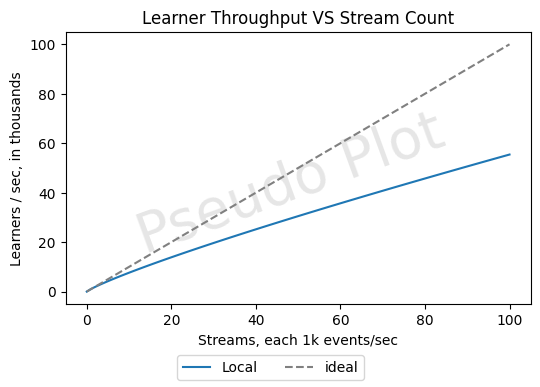

In [68]:
# Base throughput rate.

x = np.linspace(0, 100, 101)

y = 1.050764356 * np.float_power(x, 0.8610870435)

fig, axes = plt.subplots(1, 1, figsize=(6, 4))


# Function Tasks ----------------------
axes.set_title("Learner Throughput VS Stream Count")
axes.set_xlabel("Streams, each 1k events/sec")
axes.set_ylabel("Learners / sec, in thousands")

axes.plot(x, y, label="Local", zorder=1)
axes.plot(x, x, label="ideal", color="grey", linestyle="--")


# fig.suptitle("")
fig.text(
    0.5, 0.5,
    "Pseudo Plot",
    fontsize=40,
    color="gray",
    alpha=0.2,
    ha="center",
    va="center",
    rotation=20,
    zorder=10,
)

handles, labels = axes.get_legend_handles_labels()

# One shared legend
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=2,
)

fig.subplots_adjust(wspace=0.2, bottom=0.2)
plt.show()

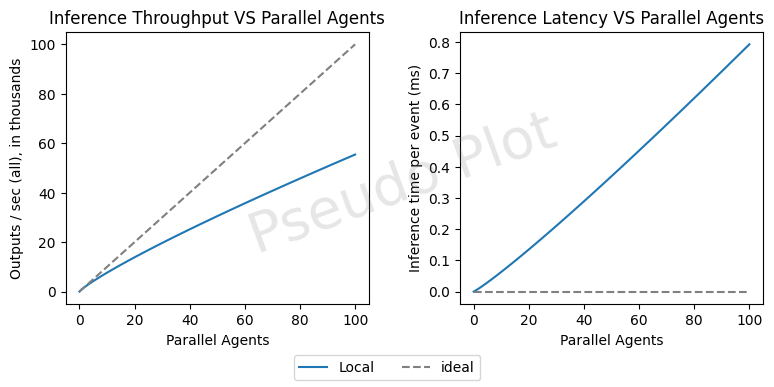

In [81]:
# Base throughput rate.

x = np.linspace(0, 100, 101)

y = 1.050764356 * np.float_power(x, 0.8610870435)
y2 = 0.005 * np.float_power(x, 1.10)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))


# Function Tasks ----------------------
axes[0].set_title("Inference Throughput VS Parallel Agents")
axes[0].set_xlabel("Parallel Agents")
axes[0].set_ylabel("Outputs / sec (all), in thousands")

axes[0].plot(x, y, label="Local", zorder=1)
axes[0].plot(x, x, label="ideal", color="grey", linestyle="--")

axes[1].set_title("Inference Latency VS Parallel Agents")
axes[1].set_xlabel("Parallel Agents")
axes[1].set_ylabel("Inference time per event (ms)")

axes[1].plot(x, y2, label="Local", zorder=1)
axes[1].plot(x, 0 * flat, label="ideal", color="grey", linestyle="--")


# fig.suptitle("")
fig.text(
    0.5, 0.5,
    "Pseudo Plot",
    fontsize=40,
    color="gray",
    alpha=0.2,
    ha="center",
    va="center",
    rotation=20,
    zorder=10,
)

handles, labels = axes[0].get_legend_handles_labels()

# One shared legend
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=2,
)

fig.subplots_adjust(wspace=0.3, bottom=0.2)
plt.show()

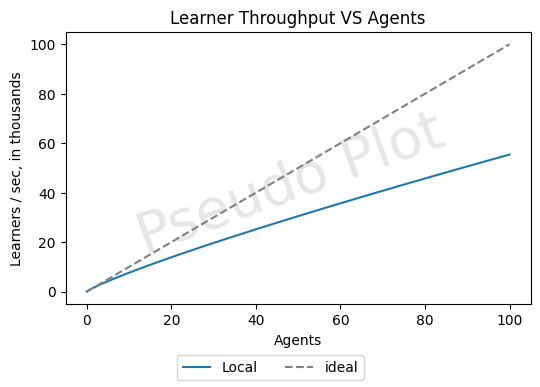

In [72]:
# Base throughput rate.

x = np.linspace(0, 100, 101)

y = 1.050764356 * np.float_power(x, 0.8610870435)

fig, axes = plt.subplots(1, 1, figsize=(6, 4))


# Function Tasks ----------------------
axes.set_title("Learner Throughput VS Agents")
axes.set_xlabel("Agents")
axes.set_ylabel("Learners / sec, in thousands")

axes.plot(x, y, label="Local", zorder=1)
axes.plot(x, x, label="ideal", color="grey", linestyle="--")


# fig.suptitle("")
fig.text(
    0.5, 0.5,
    "Pseudo Plot",
    fontsize=40,
    color="gray",
    alpha=0.2,
    ha="center",
    va="center",
    rotation=20,
    zorder=10,
)

handles, labels = axes.get_legend_handles_labels()

# One shared legend
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=2,
)

fig.subplots_adjust(wspace=0.2, bottom=0.2)
plt.show()

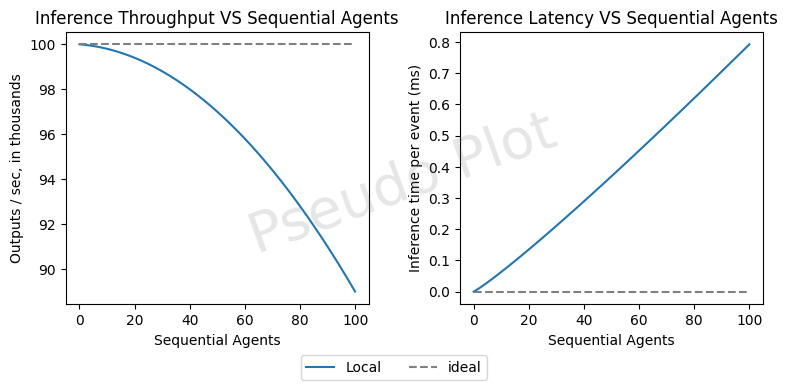

In [90]:
# Base throughput rate.

x = np.linspace(0, 100, 101)

y = 0.01 * x + 0.001 * x * x
y2 = 0.005 * np.float_power(x, 1.10)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))


# Function Tasks ----------------------
axes[0].set_title("Inference Throughput VS Sequential Agents")
axes[0].set_xlabel("Sequential Agents")
axes[0].set_ylabel("Outputs / sec, in thousands")

axes[0].plot(x, 100 - y, label="Local", zorder=1)
axes[0].plot(x, 100 * flat, label="ideal", color="grey", linestyle="--")

axes[1].set_title("Inference Latency VS Sequential Agents")
axes[1].set_xlabel("Sequential Agents")
axes[1].set_ylabel("Inference time per event (ms)")

axes[1].plot(x, y2, label="Local", zorder=1)
axes[1].plot(x, 0 * flat, label="ideal", color="grey", linestyle="--")


# fig.suptitle("")
fig.text(
    0.5, 0.5,
    "Pseudo Plot",
    fontsize=40,
    color="gray",
    alpha=0.2,
    ha="center",
    va="center",
    rotation=20,
    zorder=10,
)

handles, labels = axes[0].get_legend_handles_labels()

# One shared legend
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=2,
)

fig.subplots_adjust(wspace=0.3, bottom=0.2)
plt.show()